In [ ]:
!pip install optuna tqdm scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.2 MB/s eta 0:00:00


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.8 MB/s eta 0:00:00


In [ ]:
# Paso 0: configuración de entorno estable
import os
# Desactivar compiladores dinámicos de PyTorch que causan el error
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["PYTORCH_JIT_DISABLE"] = "1"

# Paso 1: importaciones
import torch, pickle
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score
import optuna
from tqdm import tqdm
import gensim   # NUEVO: para cargar embeddings FastText
import numpy as np



In [ ]:
# Paso 2: cargar archivos guardados
with open("vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

X_train_tensor = torch.load("X_train.pt")
y_train_tensor = torch.load("y_train.pt")
X_test_tensor = torch.load("X_test.pt")
y_test_tensor = torch.load("y_test.pt")
embedding_matrix = torch.load("embedding_matrix.pt")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


In [ ]:
# Paso 3: Modelo con mejoras
class CNN_BiGRU_v2(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, embedding_matrix, num_filters=100, dropout_rate=0.3):
        super(CNN_BiGRU_v2, self).__init__()

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout_rate)

        self.num_filters = num_filters
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes

        # CNN multi-filtro
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in [3, 5, 7]
        ])

        # BiGRU
        self.bigru = nn.GRU(embed_dim, hidden_dim, num_layers=1, bidirectional=True, batch_first=True)

        # Atención
        self.attention = nn.Linear(hidden_dim*2, 1)

        # No definimos self.fc aquí todavía
        self.fc = None

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)

        # CNN
        cnn_outs = [torch.max(torch.relu(conv(x.transpose(1,2))), dim=2)[0] for conv in self.convs]
        cnn_out = torch.cat(cnn_outs, dim=1)

        # BiGRU + atención
        gru_out, _ = self.bigru(x)
        attn_weights = torch.softmax(self.attention(gru_out), dim=1)
        attn_out = torch.sum(gru_out * attn_weights, dim=1)

        combined = torch.cat((cnn_out, attn_out), dim=1)
        combined = self.dropout(combined)

        # Crear self.fc dinámicamente en el primer forward
        if self.fc is None:
            in_features = combined.size(1)
            self.fc = nn.Linear(in_features, self.num_classes).to(combined.device)

        return self.fc(combined)



In [ ]:
# Paso 4: definir función objetivo para Optuna
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 5e-2, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    dropout_rate = trial.suggest_float("dropout", 0.2, 0.5)
    num_filters = trial.suggest_categorical("num_filters", [50, 100, 200])


    model = CNN_BiGRU_v2(
        vocab_size=len(vocab),
        embed_dim=embedding_matrix.shape[1],
        hidden_dim=hidden_dim,
        num_classes=2,
        pad_idx=0,
        embedding_matrix=embedding_matrix
    ).to(device)

    model.dropout = nn.Dropout(dropout_rate)  # reemplaza el dropout fijo
    model.convs = nn.ModuleList([
        nn.Conv1d(in_channels=embedding_matrix.shape[1], out_channels=num_filters, kernel_size=k)
        for k in [3, 5, 7]
    ])  # reemplaza los filtros fijos (100)


    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Calcular pesos de clase según distribución real
    class_counts = torch.bincount(y_train_tensor)
    total = class_counts.sum().float()
    weights = total / class_counts.float()
    weights = weights / weights.sum()  # opcional normalización

    criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    for epoch in range(3):
        model.train()
        for X_batch, y_batch in tqdm(train_loader, desc=f"Trial {trial.number} Epoch {epoch+1} [Train]", leave=False, dynamic_ncols=True):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_val, y_val in tqdm(test_loader, desc=f"Trial {trial.number} [Val]", leave=False, dynamic_ncols=True):
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs_val = model(X_val)
            _, predicted_val = torch.max(outputs_val, 1)
            y_true.extend(y_val.cpu().tolist())
            y_pred.extend(predicted_val.cpu().tolist())

    return f1_score(y_true, y_pred, average="macro")


In [ ]:
# Paso 5: ejecutar búsqueda con n_jobs=1
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, n_jobs=1)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor F1 macro:", study.best_value)


[I 2026-06-13 04:13:11,029] A new study created in memory with name: no-name-03733813-d2e8-40b9-aebb-1caee8059268
[I 2026-06-13 04:15:00,816] Trial 0 finished with value: 0.6730782090855018 and parameters: {'lr': 0.0004969094782666866, 'hidden_dim': 256, 'batch_size': 16, 'dropout': 0.25772521122538544, 'num_filters': 200}. Best is trial 0 with value: 0.6730782090855018.
[I 2026-06-13 04:15:32,303] Trial 1 finished with value: 0.6283426283426283 and parameters: {'lr': 3.624626480109835e-05, 'hidden_dim': 128, 'batch_size': 128, 'dropout': 0.28171246188155885, 'num_filters': 50}. Best is trial 0 with value: 0.6730782090855018.
[I 2026-06-13 04:17:36,174] Trial 2 finished with value: 0.6809085328422345 and parameters: {'lr': 0.0027289710053144487, 'hidden_dim': 512, 'batch_size': 64, 'dropout': 0.3432118034911644, 'num_filters': 50}. Best is trial 2 with value: 0.6809085328422345.
[I 2026-06-13 04:27:10,784] Trial 3 finished with value: 0.6309575078954924 and parameters: {'lr': 0.0496653

Mejores hiperparámetros: {'lr': 0.0027289710053144487, 'hidden_dim': 512, 'batch_size': 64, 'dropout': 0.3432118034911644, 'num_filters': 50}
Mejor F1 macro: 0.6809085328422345


In [ ]:
# Paso 6: entrenamiento final con early stopping
best_params = study.best_params
model = CNN_BiGRU_v2(
    vocab_size=len(vocab),
    embed_dim=embedding_matrix.shape[1],
    hidden_dim=best_params["hidden_dim"],
    num_classes=2,
    pad_idx=0,
    embedding_matrix=embedding_matrix
).to(device)

optimizer = optim.Adam(model.parameters(), lr=best_params["lr"])


# Calcular pesos de clase según distribución real
class_counts = torch.bincount(y_train_tensor)
total = class_counts.sum().float()
weights = total / class_counts.float()
weights = weights / weights.sum()  # opcional normalización

criterion = nn.CrossEntropyLoss(weight=weights.to(device))


train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_params["batch_size"])

best_val_f1 = 0
best_epoch = 0
patience = 3
epochs_no_improve = 0
max_epochs = 15

for epoch in range(max_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]", leave=True, dynamic_ncols=True):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    y_true, y_pred = [], []
    val_loss = 0
    with torch.no_grad():
        for X_val, y_val in tqdm(test_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Val]", leave=True, dynamic_ncols=True):
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs_val = model(X_val)
            loss_val = criterion(outputs_val, y_val)
            val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val, 1)
            y_true.extend(y_val.cpu().tolist())
            y_pred.extend(predicted_val.cpu().tolist())
    avg_val_loss = val_loss / len(test_loader)
    val_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val F1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_cnn_bigru_v2.pt")  # 🔹 nuevo nombre de archivo
        print(f"Mejora detectada en epoch {epoch+1}, modelo guardado en best_cnn_bigru_v2.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping activado")
            break

print(f"Entrenamiento final completo. Mejor F1 macro: {best_val_f1:.4f} en epoch {best_epoch}")


Epoch 1/15 [Val]: 100%|██████████| 11/11 [00:03<00:00,  3.26it/s]


Epoch 1: Train Loss=0.2046, Val Loss=1.5259, Val F1=0.6615
Mejora detectada en epoch 1, modelo guardado en best_cnn_bigru_v2.pt


Epoch 2/15 [Val]: 100%|██████████| 11/11 [00:02<00:00,  3.97it/s]


Epoch 2: Train Loss=0.0027, Val Loss=1.7763, Val F1=0.6479


Epoch 3/15 [Val]: 100%|██████████| 11/11 [00:03<00:00,  2.86it/s]


Epoch 3: Train Loss=0.0012, Val Loss=1.8923, Val F1=0.6439


Epoch 4/15 [Val]: 100%|██████████| 11/11 [00:03<00:00,  3.22it/s]

Epoch 4: Train Loss=0.0005, Val Loss=2.0628, Val F1=0.6336
Early stopping activado
Entrenamiento final completo. Mejor F1 macro: 0.6615 en epoch 1


Evaluación inicial CNN-BiGRU v2 (umbral estándar)
Matriz de confusión:
 [[460  93]
 [ 59  66]]
Exactitud (Accuracy): 0.7758

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.8863    0.8318    0.8582       553
           1     0.4151    0.5280    0.4648       125

    accuracy                         0.7758       678
   macro avg     0.6507    0.6799    0.6615       678
weighted avg     0.7994    0.7758    0.7857       678

ROC-AUC: 0.8078

Umbral óptimo según F1: 0.0750
Evaluación con umbral ajustado CNN-BiGRU v2
Matriz de confusión:
 [[428 125]
 [ 40  85]]
Exactitud (Accuracy): 0.7566

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.9145    0.7740    0.8384       553
           1     0.4048    0.6800    0.5075       125

    accuracy                         0.7566       678
   macro avg     0.6596    0.7270    0.6729       678
weighted avg     0.8205    0.7566    0.7774       678



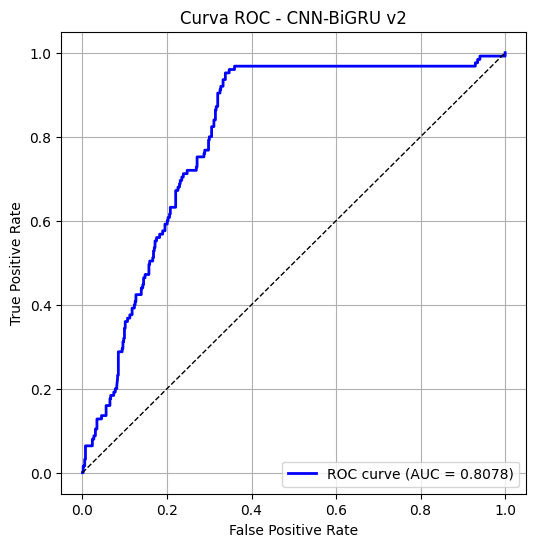

In [ ]:
# Paso 7: evaluación final CNN-BiGRU v2 con métricas y ajuste de umbral
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Cargar mejor modelo entrenado
model.load_state_dict(torch.load("best_cnn_bigru_v2.pt"))
model.eval()

# Obtener probabilidades
y_true, y_probs = [], []
with torch.no_grad():
    for X_val, y_val in test_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)
        outputs_val = model(X_val)
        probs = torch.softmax(outputs_val, dim=1)[:,1]  # prob clase positiva
        y_true.extend(y_val.cpu().tolist())
        y_probs.extend(probs.cpu().tolist())

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# --- Evaluación inicial (umbral estándar 0.5) ---
y_pred_default = (y_probs >= 0.5).astype(int)
cm_def = confusion_matrix(y_true, y_pred_default)
acc_def = (y_pred_default == y_true).mean()
print("Evaluación inicial CNN-BiGRU v2 (umbral estándar)")
print("Matriz de confusión:\n", cm_def)
print(f"Exactitud (Accuracy): {acc_def:.4f}\n")
print("Reporte de clasificación:\n")
print(classification_report(y_true, y_pred_default, digits=4))
roc_auc = roc_auc_score(y_true, y_probs)
print(f"ROC-AUC: {roc_auc:.4f}\n")

# --- Búsqueda de umbral óptimo según F1 ---
thresholds = np.linspace(0,1,201)
best_thr, best_f1 = 0.5, 0
for thr in thresholds:
    y_pred_thr = (y_probs >= thr).astype(int)
    f1_thr = f1_score(y_true, y_pred_thr, average="macro")
    if f1_thr > best_f1:
        best_f1 = f1_thr
        best_thr = thr
print(f"Umbral óptimo según F1: {best_thr:.4f}")

# --- Evaluación con umbral ajustado ---
y_pred_opt = (y_probs >= best_thr).astype(int)
cm_opt = confusion_matrix(y_true, y_pred_opt)
acc_opt = (y_pred_opt == y_true).mean()
print("Evaluación con umbral ajustado CNN-BiGRU v2")
print("Matriz de confusión:\n", cm_opt)
print(f"Exactitud (Accuracy): {acc_opt:.4f}\n")
print("Reporte de clasificación:\n")
print(classification_report(y_true, y_pred_opt, digits=4))
print(f"ROC-AUC: {roc_auc:.4f}\n")

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_true, y_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1], color="black", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - CNN-BiGRU v2")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("curva_roc_cnn_bigru_v2.png")
plt.show()
